#  Exploratory Data Analysis (EDA)


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Dataset

In [2]:
df = pd.read_csv('../data/online_shoppers_intention.csv')

print(f'Dataset shape: {df.shape}')
print(f'Number of records : {df.shape[0]}')
print(f'Number of features: {df.shape[1]}')
df.head()

Dataset shape: (12330, 18)
Number of records : 12330
Number of features: 18


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 3. Dataset Overview

In [3]:
print('=== Data Types & Non-Null Counts ===')
df.info()

=== Data Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null

In [4]:
print('=== Statistical Summary (Numerical Features) ===')
print(df.describe().T.to_string())

=== Statistical Summary (Numerical Features) ===
                           count         mean          std  min         25%         50%          75%           max
Administrative           12330.0     2.315166     3.321784  0.0    0.000000    1.000000     4.000000     27.000000
Administrative_Duration  12330.0    80.818611   176.779107  0.0    0.000000    7.500000    93.256250   3398.750000
Informational            12330.0     0.503569     1.270156  0.0    0.000000    0.000000     0.000000     24.000000
Informational_Duration   12330.0    34.472398   140.749294  0.0    0.000000    0.000000     0.000000   2549.375000
ProductRelated           12330.0    31.731468    44.475503  0.0    7.000000   18.000000    38.000000    705.000000
ProductRelated_Duration  12330.0  1194.746220  1913.669288  0.0  184.137500  598.936905  1464.157214  63973.522230
BounceRates              12330.0     0.022191     0.048488  0.0    0.000000    0.003112     0.016813      0.200000
ExitRates                12330.

## 4. Feature Descriptions

| Feature | Type | Description |
|---|---|---|
| Administrative | Numerical | Number of administrative pages visited |
| Administrative_Duration | Numerical | Time spent on administrative pages (seconds) |
| Informational | Numerical | Number of informational pages visited |
| Informational_Duration | Numerical | Time spent on informational pages (seconds) |
| ProductRelated | Numerical | Number of product-related pages visited |
| ProductRelated_Duration | Numerical | Time spent on product-related pages (seconds) |
| BounceRates | Numerical | Avg bounce rate of pages visited (0–1) |
| ExitRates | Numerical | Avg exit rate of pages visited (0–1) |
| PageValues | Numerical | Avg page value of pages visited |
| SpecialDay | Numerical | Closeness to a special day (0–1) |
| Month | Categorical | Month of the session |
| OperatingSystems | Categorical | Operating system used |
| Browser | Categorical | Browser used |
| Region | Categorical | Geographic region |
| TrafficType | Categorical | Traffic source type |
| VisitorType | Categorical | New Visitor / Returning Visitor / Other |
| Weekend | Boolean | Whether session was on a weekend |
| **Revenue** | **Boolean** | **TARGET — whether purchase was made** |

## 5. Missing Values & Duplicates

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

print('=== Missing Values ===')
print(missing_df[missing_df['Missing Count'] > 0] if missing_df['Missing Count'].sum() > 0 else 'No missing values found.')

duplicates = df.duplicated().sum()
print(f'\n=== Duplicate Records ===')
print(f'Number of duplicates: {duplicates}')
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f'Duplicates removed. New shape: {df.shape}')

=== Missing Values ===
No missing values found.

=== Duplicate Records ===
Number of duplicates: 125
Duplicates removed. New shape: (12205, 18)


## 6. Target Variable Distribution

=== Target Variable (Revenue) Distribution ===
No Purchase (FALSE):  10297 (84.4%)
Purchase   (TRUE) :   1908 (15.6%)

Class Imbalance Ratio: 5.4:1


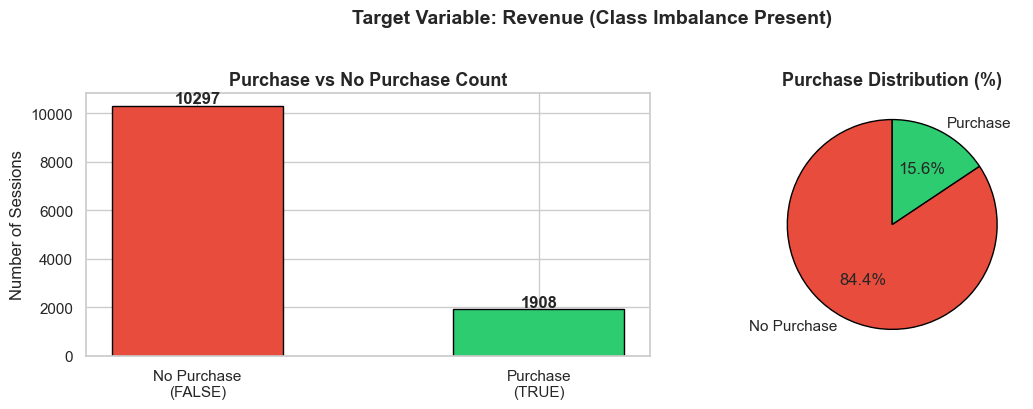

In [6]:
revenue_counts = df['Revenue'].value_counts()
revenue_pct = df['Revenue'].value_counts(normalize=True) * 100

print('=== Target Variable (Revenue) Distribution ===')
print(f'No Purchase (FALSE): {revenue_counts[False]:>6} ({revenue_pct[False]:.1f}%)')
print(f'Purchase   (TRUE) : {revenue_counts[True]:>6} ({revenue_pct[True]:.1f}%)')
print(f'\nClass Imbalance Ratio: {revenue_counts[False]/revenue_counts[True]:.1f}:1')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ['#e74c3c', '#2ecc71']
axes[0].bar(['No Purchase\n(FALSE)', 'Purchase\n(TRUE)'], revenue_counts.values, color=colors, edgecolor='black', width=0.5)
for i, v in enumerate(revenue_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Purchase vs No Purchase Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Sessions')

# Pie chart
axes[1].pie(revenue_counts.values, labels=['No Purchase', 'Purchase'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Purchase Distribution (%)', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Revenue (Class Imbalance Present)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Numerical Feature Distributions

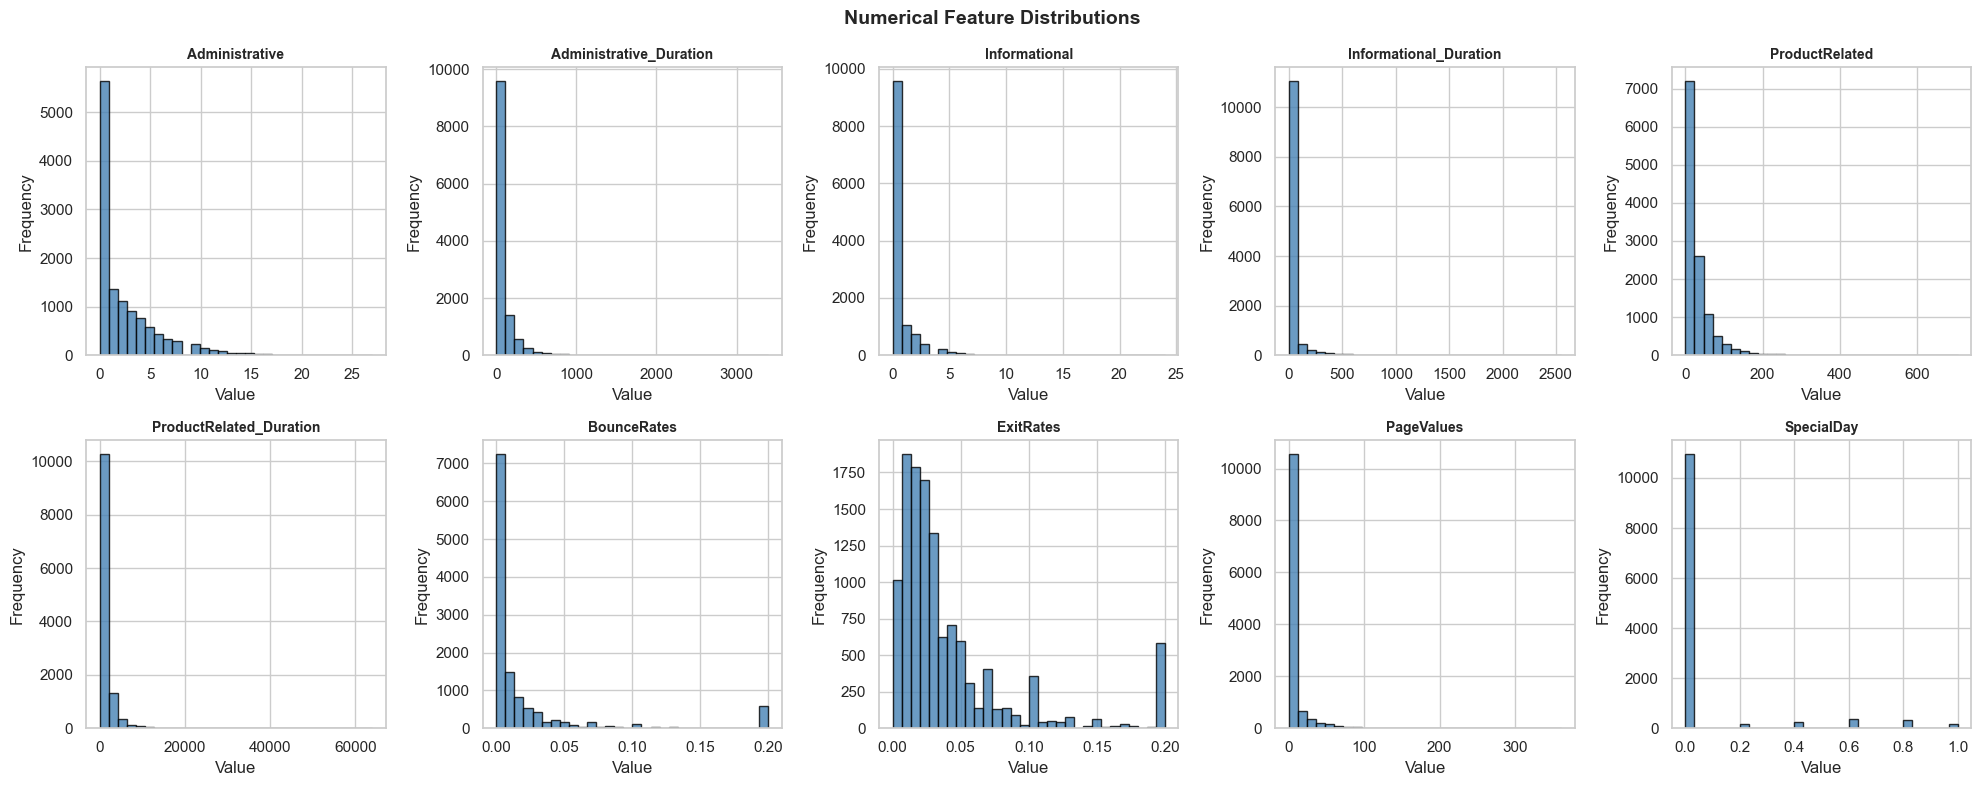

In [7]:
num_cols = ['Administrative', 'Administrative_Duration', 'Informational',
            'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
            'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Categorical Feature Distributions

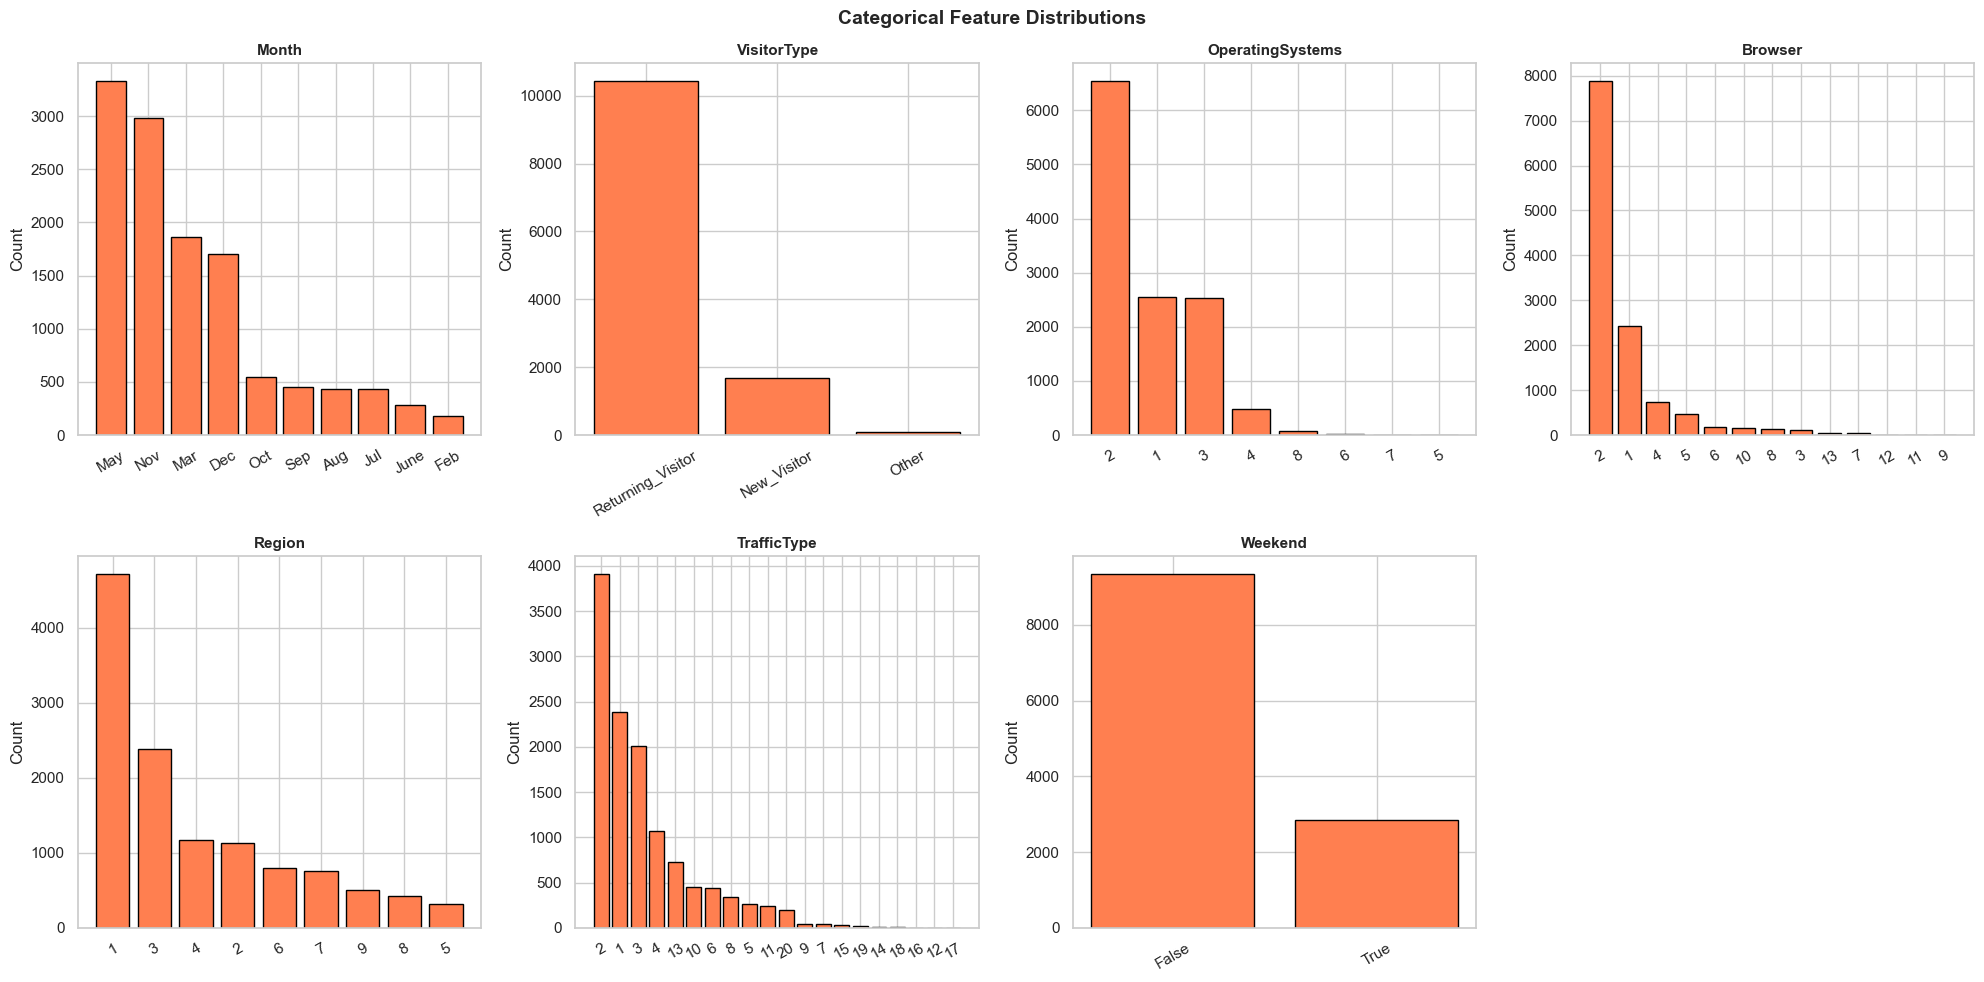

In [8]:
cat_cols = ['Month', 'VisitorType', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index.astype(str), counts.values, color='coral', edgecolor='black')
    axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)

axes[-1].axis('off')
plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Feature vs Target Analysis

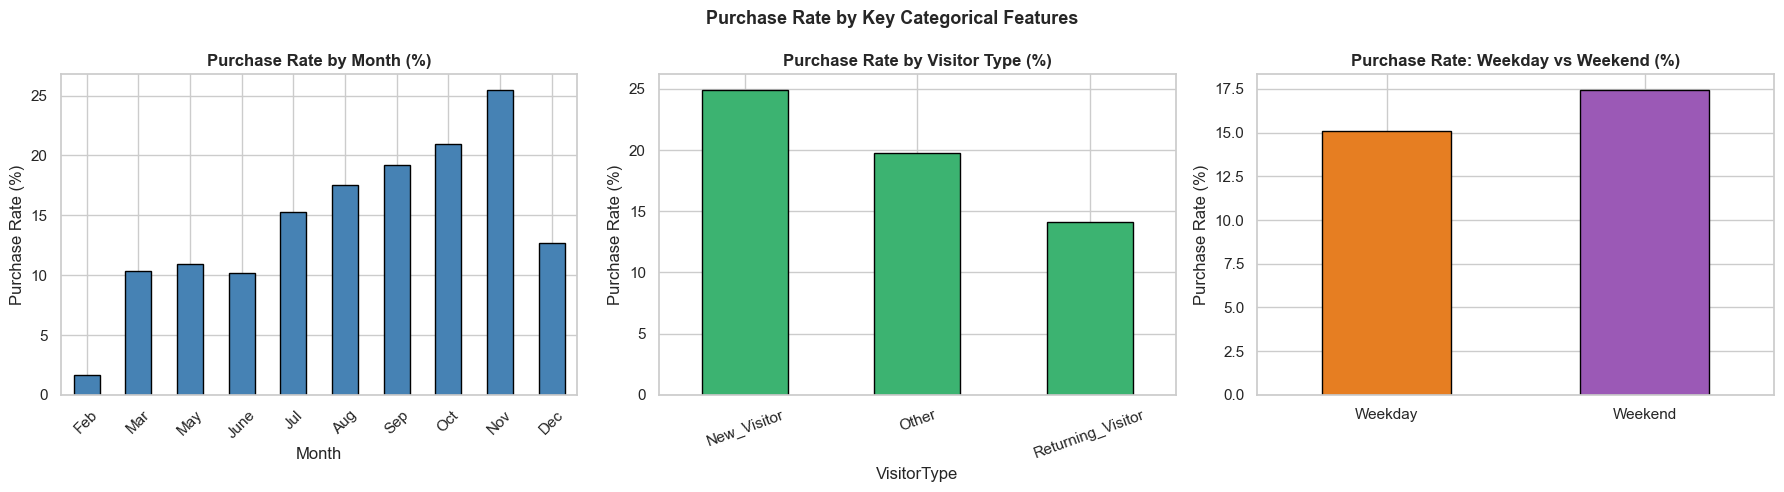

In [9]:
# Purchase rate by Month
monthly = df.groupby('Month')['Revenue'].mean().sort_values(ascending=False) * 100
month_order = ['Jan','Feb','Mar','Apr','May','June','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = monthly.reindex([m for m in month_order if m in monthly.index])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

monthly.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Purchase Rate by Month (%)', fontweight='bold')
axes[0].set_ylabel('Purchase Rate (%)')
axes[0].tick_params(axis='x', rotation=45)

# Purchase rate by VisitorType
visitor = df.groupby('VisitorType')['Revenue'].mean() * 100
visitor.plot(kind='bar', ax=axes[1], color='mediumseagreen', edgecolor='black')
axes[1].set_title('Purchase Rate by Visitor Type (%)', fontweight='bold')
axes[1].set_ylabel('Purchase Rate (%)')
axes[1].tick_params(axis='x', rotation=20)

# Purchase rate: Weekend vs Weekday
weekend = df.groupby('Weekend')['Revenue'].mean() * 100
weekend.index = ['Weekday', 'Weekend']
weekend.plot(kind='bar', ax=axes[2], color=['#e67e22', '#9b59b6'], edgecolor='black')
axes[2].set_title('Purchase Rate: Weekday vs Weekend (%)', fontweight='bold')
axes[2].set_ylabel('Purchase Rate (%)')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('Purchase Rate by Key Categorical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

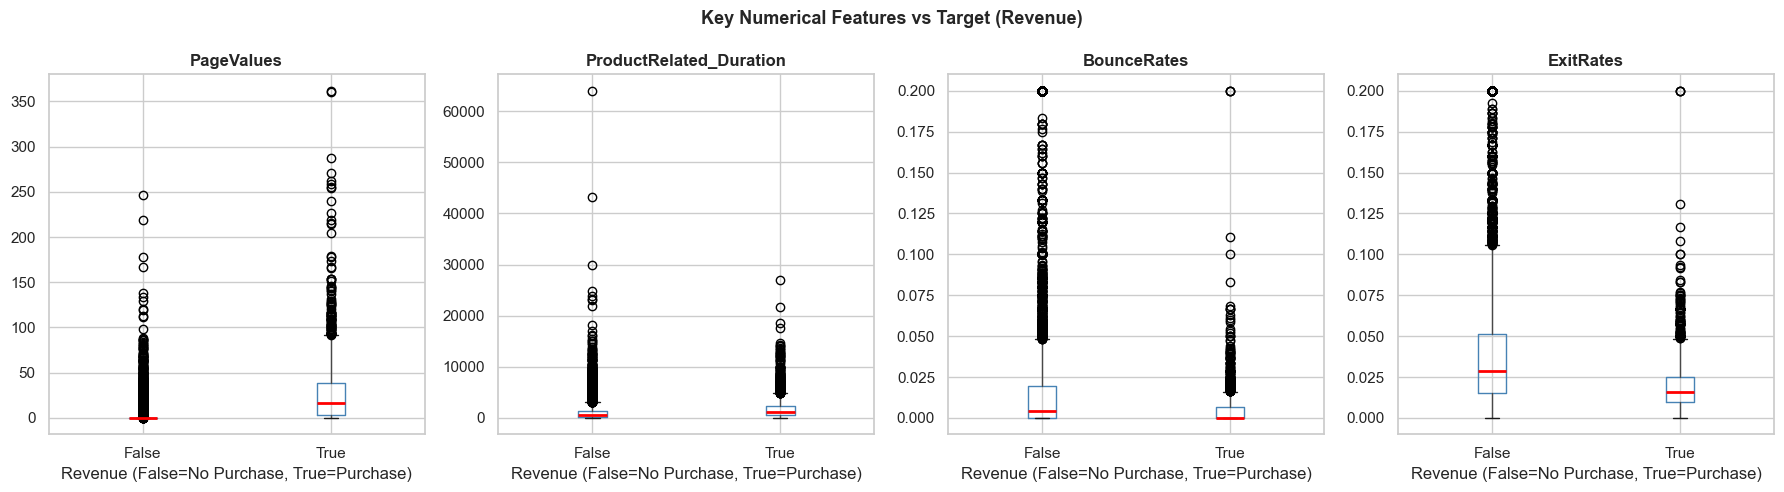

In [10]:
# Boxplots: numerical features split by Revenue
key_num = ['PageValues', 'ProductRelated_Duration', 'BounceRates', 'ExitRates']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(key_num):
    df.boxplot(column=col, by='Revenue', ax=axes[i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Revenue (False=No Purchase, True=Purchase)')

plt.suptitle('Key Numerical Features vs Target (Revenue)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Correlation Heatmap

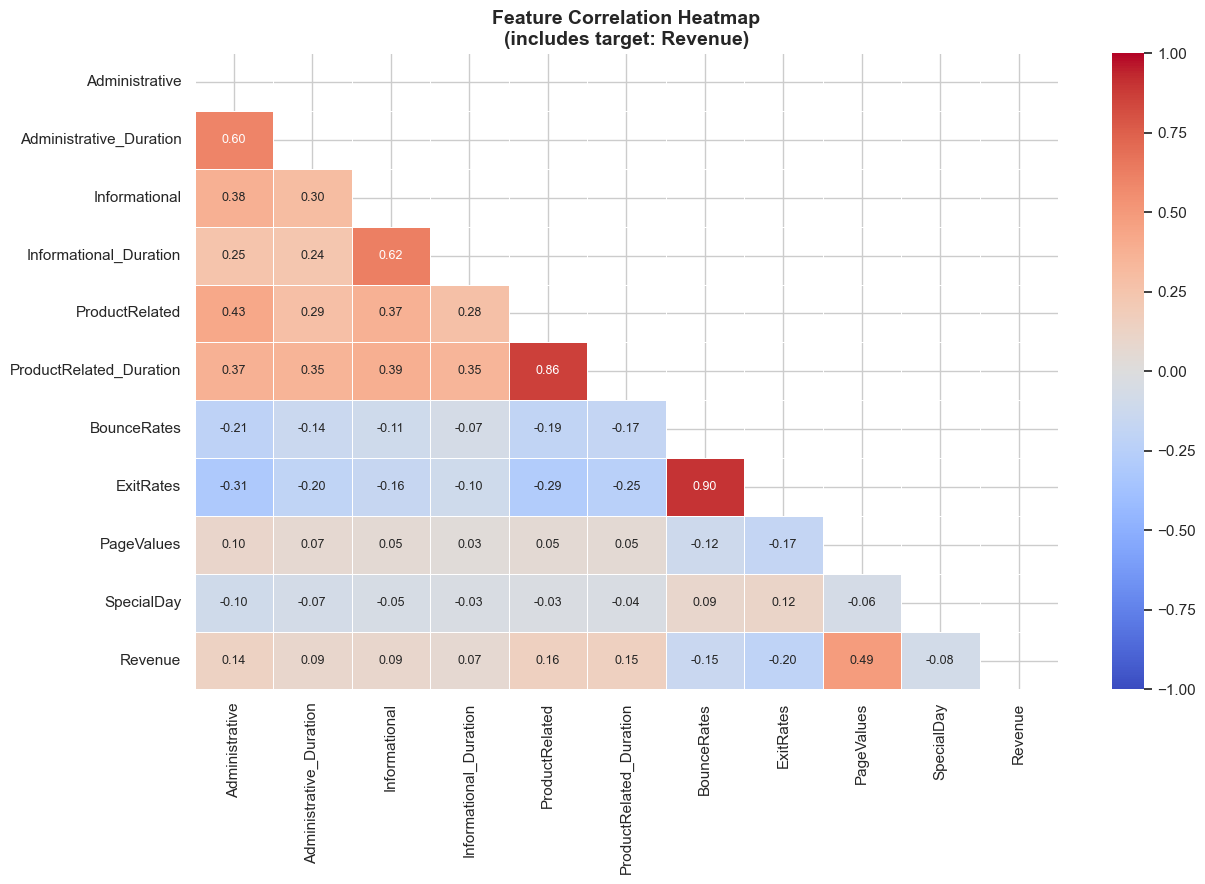

In [11]:
df_corr = df.copy()
df_corr['Revenue'] = df_corr['Revenue'].astype(int)
df_corr['Weekend'] = df_corr['Weekend'].astype(int)

corr_matrix = df_corr[num_cols + ['Revenue']].corr()

plt.figure(figsize=(13, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap\n(includes target: Revenue)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Correlation with Target Variable

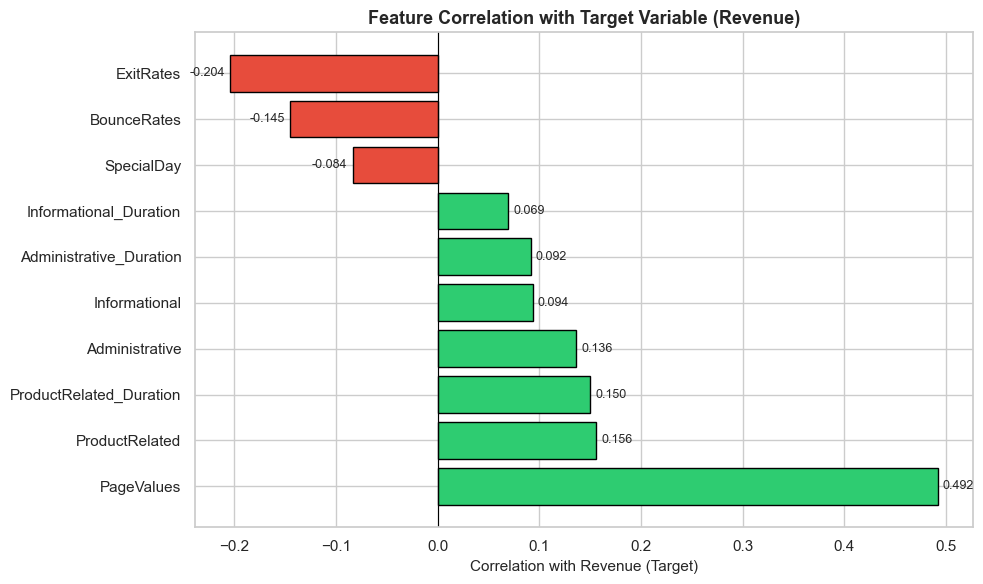


Top positive correlations with Revenue:
PageValues                 0.491894
ProductRelated             0.156042
ProductRelated_Duration    0.150077
Administrative             0.136330
Informational              0.093626
Name: Revenue, dtype: float64

Top negative correlations with Revenue:
Administrative_Duration    0.091768
Informational_Duration     0.069358
SpecialDay                -0.083601
BounceRates               -0.145091
ExitRates                 -0.204320
Name: Revenue, dtype: float64


In [12]:
target_corr = corr_matrix['Revenue'].drop('Revenue').sort_values(ascending=False)

colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in target_corr.values]

plt.figure(figsize=(10, 6))
bars = plt.barh(target_corr.index, target_corr.values, color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Correlation with Revenue (Target)', fontsize=11)
plt.title('Feature Correlation with Target Variable (Revenue)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, target_corr.values):
    plt.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

print('\nTop positive correlations with Revenue:')
print(target_corr.head(5))
print('\nTop negative correlations with Revenue:')
print(target_corr.tail(5))

## 12. Outlier Detection

In [13]:
print('=== Outlier Detection (IQR Method) ===')
outlier_summary = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = round(n_outliers / len(df) * 100, 2)
    outlier_summary.append({'Feature': col, 'Lower Bound': round(lower, 4),
                             'Upper Bound': round(upper, 4),
                             'Outlier Count': n_outliers, 'Outlier %': pct})

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

=== Outlier Detection (IQR Method) ===
                Feature  Lower Bound  Upper Bound  Outlier Count  Outlier %
         Administrative      -6.0000      10.0000            404       3.31
Administrative_Duration    -142.0500     236.7500           1149       9.41
          Informational       0.0000       0.0000           2631      21.56
 Informational_Duration       0.0000       0.0000           2405      19.71
         ProductRelated     -37.0000      83.0000           1007       8.25
ProductRelated_Duration   -1733.2321    3403.3869            951       7.79
            BounceRates      -0.0250       0.0417           1428      11.70
              ExitRates      -0.0372       0.1000           1325      10.86
             PageValues       0.0000       0.0000           2730      22.37
             SpecialDay       0.0000       0.0000           1249      10.23


## 13. EDA Summary & Key Findings

In [14]:
print('=' * 60)
print('          EDA SUMMARY — KEY FINDINGS')
print('=' * 60)

print(f'''
DATASET
  Source      : UCI ML Repository — Online Shoppers Intention
  Records     : {df.shape[0]:,}
  Features    : {df.shape[1]} (17 inputs + 1 target)
  Target      : Revenue (Binary: Purchase / No Purchase)

DATA QUALITY
  Missing values  : None
  Duplicate rows  : {duplicates} (removed if any)

CLASS IMBALANCE
  No Purchase (FALSE) : {revenue_counts[False]:,} ({revenue_pct[False]:.1f}%)
  Purchase    (TRUE)  : {revenue_counts[True]:,}  ({revenue_pct[True]:.1f}%)
  → Imbalanced dataset: must use class_weight or SMOTE in modeling

KEY INSIGHTS
  1. PageValues is the strongest predictor of purchase
     (higher page value = more likely to purchase)
  2. BounceRates and ExitRates are negatively correlated
     with Revenue (high bounce = low purchase intent)
  3. November has the highest purchase rate (holiday season)
  4. New Visitors convert at a higher rate than Returning Visitors
  5. ProductRelated pages visited correlates with purchase intent
  6. Significant outliers in ProductRelated_Duration, 
     Administrative_Duration — need treatment in Feature Engineering


''')

          EDA SUMMARY — KEY FINDINGS

DATASET
  Source      : UCI ML Repository — Online Shoppers Intention
  Records     : 12,205
  Features    : 18 (17 inputs + 1 target)
  Target      : Revenue (Binary: Purchase / No Purchase)

DATA QUALITY
  Missing values  : None
  Duplicate rows  : 125 (removed if any)

CLASS IMBALANCE
  No Purchase (FALSE) : 10,297 (84.4%)
  Purchase    (TRUE)  : 1,908  (15.6%)
  → Imbalanced dataset: must use class_weight or SMOTE in modeling

KEY INSIGHTS
  1. PageValues is the strongest predictor of purchase
     (higher page value = more likely to purchase)
  2. BounceRates and ExitRates are negatively correlated
     with Revenue (high bounce = low purchase intent)
  3. November has the highest purchase rate (holiday season)
  4. New Visitors convert at a higher rate than Returning Visitors
  5. ProductRelated pages visited correlates with purchase intent
  6. Significant outliers in ProductRelated_Duration, 
     Administrative_Duration — need treatment in